# From Clean Mental Models → Deep ML Examples (Comprehensive Notebook)
This notebook starts with **clean mental models** (intuition first), then goes deeper with **complete, runnable examples**.

## Contents
1. Clean mental models (what a model is, what training is, what data is)
2. The math anchors (probability, loss, empirical vs expected risk)
3. Core supervised algorithms (linear/logistic, trees, ensembles, SVM, neural nets)
4. Unsupervised algorithms (k-means, PCA)
5. Evaluation, thresholds, calibration
6. Sampling, imbalance, weighting
7. Distribution shift + monitoring mini-simulations

> Designed for Google Colab / Jupyter. Run top-to-bottom.


## 0) Setup

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(0)

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, classification_report,
                             mean_squared_error, r2_score, precision_recall_curve, roc_curve,
                             brier_score_loss)


---
# Metrics & Curves Glossary (Definitions)
This section explains the evaluation tools used throughout the notebook.

## Classification metrics
**Confusion matrix terms** (binary classification):
- **TP**: true positives (pred=1, actual=1)
- **TN**: true negatives (pred=0, actual=0)
- **FP**: false positives (pred=1, actual=0)
- **FN**: false negatives (pred=0, actual=1)

### `accuracy_score`
Fraction of correct predictions:
$$
\text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}
$$

### `precision_score`
Of the predicted positives, how many were truly positive:
$$
\text{Precision} = \frac{TP}{TP + FP}
$$

### `recall_score`
Of the actual positives, how many did we catch (aka sensitivity/TPR):
$$
\text{Recall} = \frac{TP}{TP + FN}
$$

### `f1_score`
Harmonic mean of precision and recall (useful with imbalance):
$$
F_1 = 2\cdot\frac{\text{Precision}\cdot\text{Recall}}{\text{Precision}+\text{Recall}}
$$

### `roc_auc_score`
Area under the ROC curve (ranking quality). Equivalent interpretation:
- Probability that a random positive is scored higher than a random negative.

### `confusion_matrix`
Returns the 2×2 table of counts:
$$
\begin{bmatrix}
TN & FP\\
FN & TP
\end{bmatrix}
$$

### `classification_report`
Convenience summary of precision/recall/F1 per class + support (counts).

## Curves
### `roc_curve`
Computes points for the ROC curve across thresholds:
- **TPR** (recall) vs **FPR** where $\text{FPR}=\frac{FP}{FP+TN}$

### `precision_recall_curve`
Computes precision vs recall across thresholds.
- Often more informative than ROC when positives are rare.

## Regression metrics
### `mean_squared_error`
Average squared prediction error:
$$
\text{MSE}=\frac{1}{n}\sum_{i=1}^n (y_i-\hat{y}_i)^2
$$

### `r2_score`
Explained variance relative to predicting the mean:
$$
R^2 = 1 - \frac{\sum (y_i-\hat{y}_i)^2}{\sum (y_i-\bar{y})^2}
$$

## Probability calibration metric
### `brier_score_loss`
Measures the mean squared error of predicted probabilities (lower is better):
$$
\text{Brier} = \frac{1}{n}\sum_{i=1}^n (p_i - y_i)^2
$$

### When to prefer which
- **Accuracy**: ok when classes are balanced and costs symmetric
- **Precision/Recall/F1**: better for imbalance or asymmetric costs
- **ROC-AUC**: ranking quality across thresholds
- **PR curve**: best for rare positives
- **Brier score**: probability quality (calibration)


 **ROC AUC** (Area Under the Receiver Operating Characteristic Curve) evaluates binary classifiers, showing how well a model distinguishes positive from negative classes across all thresholds, with AUC as a single score (0-1):

  1.0 is perfect
  0.5 is random guessing
   
   indicating model's ability to rank positives higher than negatives.

### Mini-demo: ROC curve, PR curve, and classification report
Run this after training any model that outputs probabilities (we'll use logistic regression later in the notebook too).


              precision    recall  f1-score   support

           0     0.8592    0.9929    0.9212       424
           1     0.7000    0.0921    0.1628        76

    accuracy                         0.8560       500
   macro avg     0.7796    0.5425    0.5420       500
weighted avg     0.8350    0.8560    0.8059       500

ROC-AUC: 0.7381
Brier : 0.1081


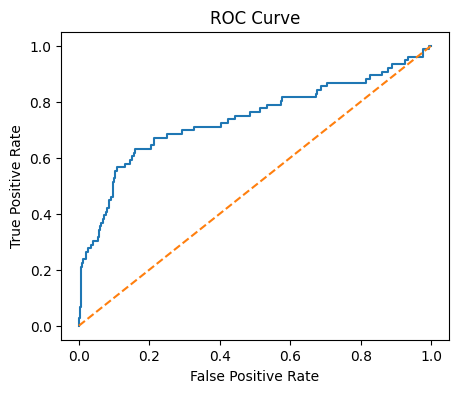

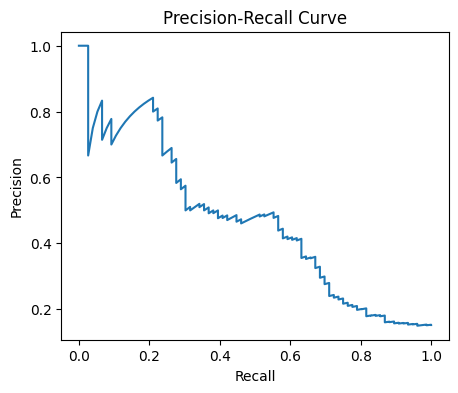

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler # Added this import
from sklearn.metrics import classification_report, roc_auc_score, brier_score_loss, roc_curve, precision_recall_curve
import matplotlib.pyplot as plt # Added this import

# Small demo dataset
Xd, yd = make_classification(n_samples=2000, n_features=10, n_informative=4,
                            n_redundant=2, weights=[0.85, 0.15], random_state=0)

Xtr, Xte, ytr, yte = train_test_split(Xd, yd, test_size=0.25, random_state=0, stratify=yd)

demo_model = Pipeline([("scaler", StandardScaler()),
                      ("clf", LogisticRegression(max_iter=2000))])
demo_model.fit(Xtr, ytr)

p = demo_model.predict_proba(Xte)[:,1]
yhat = (p >= 0.5).astype(int)

print(classification_report(yte, yhat, digits=4))
print("ROC-AUC:", round(roc_auc_score(yte, p), 4))
print("Brier :", round(brier_score_loss(yte, p), 4))

# ROC curve
fpr, tpr, _ = roc_curve(yte, p)
fig, ax = plt.subplots(figsize=(5,4))
ax.plot(fpr, tpr)
ax.plot([0,1],[0,1], linestyle="--")
ax.set_title("ROC Curve")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
plt.show()

# Precision-Recall curve
prec, rec, _ = precision_recall_curve(yte, p)
fig, ax = plt.subplots(figsize=(5,4))
ax.plot(rec, prec)
ax.set_title("Precision-Recall Curve")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
plt.show()

---
# 1) Clean mental models (start here)
### 1.1 What is a model?
A **model** is a function that maps inputs to outputs:

- Inputs: features \(X\)
- Outputs: prediction \(\hat{Y}\) or probability \(\hat{P}(Y=1\mid X)

**Mental picture**: the model is a *calculator* that turns feature values into a prediction.

### 1.2 What is training?
Training means choosing model parameters to make predictions match labels on training data.

### 1.3 What is training data?
In real systems, training data is not a frozen “dataset”. It's a **sampled snapshot** of a changing world.

### 1.4 The core triangle
- **Data** (what the model sees)
- **Objective/Loss** (what we optimize)
- **Model class** (what patterns we allow)

Most production problems are caused by **data** (sampling, drift, bias), not by fancy models.


In [ ]:
# Diagram: the ML triangle (Data, Model, Objective)
fig, ax = plt.subplots(figsize=(6, 4))
ax.axis("off")

# Triangle points
pts = np.array([[0.5, 0.9], [0.1, 0.1], [0.9, 0.1]])
labels = ["Data
(training data)", "Model
(function family)", "Objective
(loss/metric)"]

# Draw triangle
ax.plot([pts[0,0], pts[1,0]], [pts[0,1], pts[1,1]], linewidth=2)
ax.plot([pts[1,0], pts[2,0]], [pts[1,1], pts[2,1]], linewidth=2)
ax.plot([pts[2,0], pts[0,0]], [pts[2,1], pts[0,1]], linewidth=2)

for (x,y), lab in zip(pts, labels):
    ax.text(x, y, lab, ha="center", va="center", fontsize=11)

ax.text(0.5, 0.02, "Better ML systems = careful data + correct objective + suitable model", ha="center", fontsize=10)
plt.show()

---
# 2) Math anchors (just enough)
We use math to express a few key truths:

### 2.1 Data-generating process
Assume the world produces examples \((X,Y)\) according to an unknown distribution \(P(X,Y)

### 2.2 Empirical risk vs expected risk
**Empirical risk** (what training minimizes):
$$
\hat{R}(f)=\frac{1}{n}\sum_{i=1}^n \ell\big(f(x_i), y_i\big)
$$

**Expected risk** (what we care about in the real world):
$$
R(f)=\mathbb{E}_{(X,Y)\sim P_{\text{real}}}\left[\ell\big(f(X), Y\big)\right]
$$

When sampling is biased or the world shifts,
\(\hat{R}(f)\) can look great while \(R(f)\) is bad.


---
# 3) A single running dataset (so examples are consistent)
### What we're trying to do
Create a synthetic dataset that behaves like many real problems:
- non-linear patterns
- noise
- optional class imbalance

### Expected output
- A scatter plot of the data
- A train/test split


In [ ]:
from sklearn.datasets import make_moons

X, y = make_moons(n_samples=3000, noise=0.25, random_state=0)

# Optional: create imbalance by dropping some positives
keep = np.ones_like(y, dtype=bool)
pos_idx = np.where(y==1)[0]
drop = np.random.choice(pos_idx, size=int(0.55*len(pos_idx)), replace=False)
keep[drop] = False
X_imb, y_imb = X[keep], y[keep]

print("Class distribution (imbalanced):", np.bincount(y_imb))

X_train, X_test, y_train, y_test = train_test_split(
    X_imb, y_imb, test_size=0.25, random_state=1, stratify=y_imb
)

fig, ax = plt.subplots(figsize=(6,5))
ax.scatter(X_train[y_train==0,0], X_train[y_train==0,1], alpha=0.5, label="Class 0")
ax.scatter(X_train[y_train==1,0], X_train[y_train==1,1], alpha=0.5, label="Class 1")
ax.set_title("Running dataset (train split)")
ax.legend()
plt.show()

---
# 4) Logistic Regression (baseline classifier)
### Clean model intuition
Logistic regression draws a **linear boundary** in feature space (after scaling).

### Expected output
- Basic metrics
- Decision boundary plot
- Precision/recall tradeoff via threshold


In [ ]:
from sklearn.linear_model import LogisticRegression

logreg = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=3000))
])
logreg.fit(X_train, y_train)

proba = logreg.predict_proba(X_test)[:,1]
pred = (proba >= 0.5).astype(int)

print("Accuracy :", round(accuracy_score(y_test, pred), 4))
print("Precision:", round(precision_score(y_test, pred, zero_division=0), 4))
print("Recall   :", round(recall_score(y_test, pred, zero_division=0), 4))
print("F1       :", round(f1_score(y_test, pred, zero_division=0), 4))
print("ROC-AUC  :", round(roc_auc_score(y_test, proba), 4))
print("Confusion matrix:\n", confusion_matrix(y_test, pred))

In [ ]:
# Decision boundary plot helper
def plot_boundary(model, X, y, title):
    x_min, x_max = X[:,0].min()-1, X[:,0].max()+1
    y_min, y_max = X[:,1].min()-1, X[:,1].max()+1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                         np.linspace(y_min, y_max, 300))
    grid = np.c_[xx.ravel(), yy.ravel()]
    zz = model.predict_proba(grid)[:,1].reshape(xx.shape)

    fig, ax = plt.subplots(figsize=(6,5))
    ax.contourf(xx, yy, zz, levels=30, alpha=0.6)
    ax.contour(xx, yy, zz, levels=[0.5], linewidths=2)
    ax.scatter(X[y==0,0], X[y==0,1], alpha=0.6, label="Class 0")
    ax.scatter(X[y==1,0], X[y==1,1], alpha=0.6, label="Class 1")
    ax.set_title(title)
    ax.legend()
    plt.show()

plot_boundary(logreg, X_test, y_test, "Logistic Regression: decision surface (p=1) + boundary (p=0.5)")

In [ ]:
# Threshold tradeoff
thresholds = np.linspace(0.05, 0.95, 10)
rows = []
for t in thresholds:
    p = (proba >= t).astype(int)
    rows.append({
        "threshold": float(np.round(t, 2)),
        "precision": precision_score(y_test, p, zero_division=0),
        "recall": recall_score(y_test, p, zero_division=0),
        "f1": f1_score(y_test, p, zero_division=0),
    })
pd.DataFrame(rows).round(4)

---
# 5) Decision Trees (rules)
### Clean model intuition
Trees split the space into rectangles using if/then rules.

### Expected output
- Metrics + boundary plot


In [ ]:
from sklearn.tree import DecisionTreeClassifier

tree = DecisionTreeClassifier(max_depth=5, random_state=0)
tree.fit(X_train, y_train)
proba_t = tree.predict_proba(X_test)[:,1]
pred_t = (proba_t >= 0.5).astype(int)

print("Accuracy:", round(accuracy_score(y_test, pred_t), 4))
print("ROC-AUC :", round(roc_auc_score(y_test, proba_t), 4))

plot_boundary(tree, X_test, y_test, "Decision Tree (max_depth=5)")

---
# 6) Random Forest (bagging many trees)
### Clean model intuition
Random Forest averages many trees trained on bootstrapped samples → reduces variance.


In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=300, random_state=0)
rf.fit(X_train, y_train)
proba_rf = rf.predict_proba(X_test)[:,1]
pred_rf = (proba_rf >= 0.5).astype(int)

print("Accuracy:", round(accuracy_score(y_test, pred_rf), 4))
print("ROC-AUC :", round(roc_auc_score(y_test, proba_rf), 4))

plot_boundary(rf, X_test, y_test, "Random Forest (300 trees)")

---
# 7) Gradient Boosting (strong tabular baseline)
Boosting trains models sequentially to fix previous errors.


In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(random_state=0)
gb.fit(X_train, y_train)
proba_gb = gb.predict_proba(X_test)[:,1]
pred_gb = (proba_gb >= 0.5).astype(int)

print("Accuracy:", round(accuracy_score(y_test, pred_gb), 4))
print("ROC-AUC :", round(roc_auc_score(y_test, proba_gb), 4))

plot_boundary(gb, X_test, y_test, "Gradient Boosting")

---
# 8) SVM (margin classifier)
SVM tries to separate classes with maximum margin; kernels allow non-linear boundaries.


In [ ]:
from sklearn.svm import SVC

svm = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", SVC(kernel="rbf", probability=True, random_state=0))
])
svm.fit(X_train, y_train)
proba_s = svm.predict_proba(X_test)[:,1]
pred_s = (proba_s >= 0.5).astype(int)

print("Accuracy:", round(accuracy_score(y_test, pred_s), 4))
print("ROC-AUC :", round(roc_auc_score(y_test, proba_s), 4))

plot_boundary(svm, X_test, y_test, "SVM (RBF kernel)")

---
# 9) Neural Network (MLP) – modern baseline idea
### Clean model intuition
A neural net stacks simple linear layers + non-linearities to learn flexible functions.


In [ ]:
from sklearn.neural_network import MLPClassifier

mlp = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", MLPClassifier(hidden_layer_sizes=(32, 32), max_iter=2000, random_state=0))
])
mlp.fit(X_train, y_train)
proba_n = mlp.predict_proba(X_test)[:,1]
pred_n = (proba_n >= 0.5).astype(int)

print("Accuracy:", round(accuracy_score(y_test, pred_n), 4))
print("ROC-AUC :", round(roc_auc_score(y_test, proba_n), 4))

plot_boundary(mlp, X_test, y_test, "Neural Net (MLP 32x32)")

---
# 10) Compare models quickly
### Expected output
A table comparing accuracy/ROC-AUC across algorithms.


In [ ]:
models = {
    "LogReg": (proba, pred),
    "Tree": (proba_t, pred_t),
    "RF": (proba_rf, pred_rf),
    "GB": (proba_gb, pred_gb),
    "SVM": (proba_s, pred_s),
    "MLP": (proba_n, pred_n),
}

rows = []
for name, (pb, pr) in models.items():
    rows.append({
        "model": name,
        "accuracy": accuracy_score(y_test, pr),
        "precision": precision_score(y_test, pr, zero_division=0),
        "recall": recall_score(y_test, pr, zero_division=0),
        "roc_auc": roc_auc_score(y_test, pb)
    })

pd.DataFrame(rows).sort_values("roc_auc", ascending=False).round(4)

---
# 11) Calibration (probabilities that mean what they say)
A model can rank well (high AUC) but give poorly calibrated probabilities.

We’ll use **Brier score** (lower is better) as a simple calibration signal.


In [ ]:
for name, (pb, pr) in models.items():
    print(name, "Brier score:", round(brier_score_loss(y_test, pb), 4))

---
# 12) Unsupervised learning: K-Means clustering
### Clean model intuition
K-Means groups points by minimizing distance to cluster centers.

### Expected output
- Cluster assignment plot and learned centers


In [ ]:
from sklearn.cluster import KMeans

km = KMeans(n_clusters=2, n_init=10, random_state=0)
labels = km.fit_predict(X_train)

fig, ax = plt.subplots(figsize=(6,5))
ax.scatter(X_train[:,0], X_train[:,1], c=labels, alpha=0.6)
ax.scatter(km.cluster_centers_[:,0], km.cluster_centers_[:,1], s=250, marker="X")
ax.set_title("K-Means (K=2) on training features")
plt.show()

km.cluster_centers_

---
# 13) Dimensionality reduction: PCA
### Clean model intuition
PCA finds directions of maximum variance and projects data to fewer dimensions.


In [ ]:
from sklearn.decomposition import PCA

X_hi = np.random.normal(0, 1, size=(2000, 12))
X_hi[:,0] = X_hi[:,0]*4 + 0.6*X_hi[:,1]  # add a strong direction

pca = PCA(n_components=2, random_state=0)
X2 = pca.fit_transform(X_hi)

print("Explained variance ratio:", np.round(pca.explained_variance_ratio_, 4))

fig, ax = plt.subplots(figsize=(6,4))
ax.scatter(X2[:,0], X2[:,1], alpha=0.5)
ax.set_title("PCA projection (12D → 2D)")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
plt.show()

---
# 14) Sampling, imbalance, and class weights
### Clean model intuition
When positives are rare, naïve training may ignore them.

We compare logistic regression:
- without class weights
- with `class_weight='balanced'`

### Expected output
- Weighted model usually increases recall for minority class.


In [ ]:
logreg_plain = Pipeline([("scaler", StandardScaler()),
                        ("clf", LogisticRegression(max_iter=3000))])
logreg_bal = Pipeline([("scaler", StandardScaler()),
                      ("clf", LogisticRegression(max_iter=3000, class_weight="balanced"))])

logreg_plain.fit(X_train, y_train)
logreg_bal.fit(X_train, y_train)

proba_p = logreg_plain.predict_proba(X_test)[:,1]
proba_b = logreg_bal.predict_proba(X_test)[:,1]
pred_p = (proba_p >= 0.5).astype(int)
pred_b = (proba_b >= 0.5).astype(int)

print("Plain  precision/recall:", round(precision_score(y_test, pred_p, zero_division=0),4),
      round(recall_score(y_test, pred_p, zero_division=0),4))
print("Balanced precision/recall:", round(precision_score(y_test, pred_b, zero_division=0),4),
      round(recall_score(y_test, pred_b, zero_division=0),4))

---
# 15) Distribution shift simulation (why training data must evolve)
### What we're trying to do
Simulate covariate shift by changing the input distribution.

### Expected output
- Model performance drops when tested on shifted data.


In [ ]:
# Train on original distribution (already trained logreg)
train_model = logreg_plain

# Create shifted test set
X_shift = X_test.copy()
X_shift[:,0] += 0.9  # shift feature distribution
y_shift = y_test.copy()  # keep labels same for this demo

proba_orig = train_model.predict_proba(X_test)[:,1]
proba_shift = train_model.predict_proba(X_shift)[:,1]

print("ROC-AUC on original test:", round(roc_auc_score(y_test, proba_orig), 4))
print("ROC-AUC on shifted test  :", round(roc_auc_score(y_shift, proba_shift), 4))

fig, ax = plt.subplots(figsize=(7,3))
ax.hist(X_test[:,0], bins=30, alpha=0.6, density=True, label="Original test x0")
ax.hist(X_shift[:,0], bins=30, alpha=0.6, density=True, label="Shifted test x0")
ax.set_title("Covariate shift: feature distribution changed")
ax.legend()
plt.show()

---
# 16) Monitoring signals (simple)
In production, you often monitor:
- feature distribution changes (drift)
- prediction distribution changes
- performance on delayed labels

Below we monitor a simple drift signal: mean/variance of a feature over time.


In [ ]:
# Simulate streaming batches where drift increases over time
batches = 30
batch_size = 400

means = []
stds = []
for t in range(batches):
    x0 = np.random.normal(loc=0.0 + 0.05*t, scale=1.0, size=batch_size)  # drifting mean
    means.append(x0.mean())
    stds.append(x0.std())

fig, ax = plt.subplots(figsize=(7,3))
ax.plot(means, marker="o", label="mean(x0) per batch")
ax.plot(stds, marker="o", label="std(x0) per batch")
ax.set_title("Simple drift monitoring signals over time")
ax.set_xlabel("batch index (time)")
ax.legend()
plt.show()

---
# 17) Reference appendix (compact)
### A) When to use what (quick heuristic)
- **Logistic Regression**: fast, interpretable baseline
- **Tree**: interpretable rules, but can overfit
- **Random Forest**: robust baseline for tabular data
- **Gradient Boosting**: often top performer on tabular data
- **SVM**: strong on small/medium datasets
- **Neural nets**: flexible, needs tuning/data
- **K-Means**: clustering
- **PCA**: compression/visualization

### B) Common pitfalls
- train/test leakage
- wrong split strategy (time problems need time splits)
- class imbalance hidden by accuracy
- drift in production
